**Normalize**

In [2]:
import pandas as pd
import numpy as np

# Load your data
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

# Separate metadata and features
meta = df[["accession", "group"]]
X = df.drop(columns=["accession", "group"]).values

# --- Normalization per sample ---
# Each sample (row) is divided by its total intensity (sum of all bins)
# This converts absolute intensities into relative proportions
row_sums = X.sum(axis=1, keepdims=True)
# Avoid division by zero
row_sums[row_sums == 0] = 1
X_norm = X / row_sums

# Optionally apply log-transform to compress large peaks (optional)
# X_norm = np.log1p(X_norm)

# Combine back into a DataFrame for downstream use
X_df = pd.DataFrame(X_norm, columns=df.columns[2:])
df_norm = pd.concat([meta, X_df], axis=1)

# Save normalized features (optional)
df_norm.to_csv("processed_data/nmr_features_with_groups_normalized.csv", index=False)

print("Normalization done. Example row sum (should be 1.0):", X_norm[0].sum())


Normalization done. Example row sum (should be 1.0): 1.0


**This code builds a baseline machine learning pipeline to evaluate how well ¹H-NMR spectra can classify metabolites into chemical groups.**

*Load data*
- Reads the preprocessed dataset where each row represents one metabolite with its binned NMR intensities (peak1…peakN) and group label.

*Standardize features*
- Scales all intensity features to zero mean and unit variance (StandardScaler), ensuring that bins with larger values don’t dominate the models.

*Visualize with PCA*
- Performs Principal Component Analysis (PCA) to project the high-dimensional spectra into 2D (PC1–PC2) for visualization of clustering patterns between groups.

*Train and evaluate models*
- Random Forest: ensemble of decision trees capturing nonlinear relationships.
- Support Vector Machine (RBF kernel): nonlinear classifier that finds separating boundaries in feature space.

Both are evaluated with 5-fold stratified cross-validation, reporting the mean and standard deviation of accuracy across folds.

The results give a first indication of how separable the metabolite groups are based on their NMR spectra and serve as a baseline for further model tuning or feature engineering.

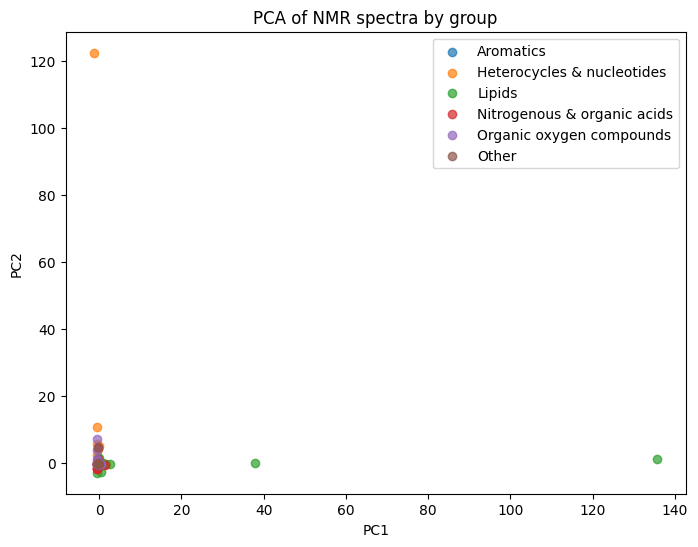

Random Forest CV accuracy: 0.566 ± 0.035
SVM CV accuracy: 0.484 ± 0.044


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# -------------------------
# 1. Load your features + groups
# -------------------------
# Suppose your CSV has columns:
# accession, group, peak1, peak2, ..., peakN
df = pd.read_csv("processed_data/nmr_features_with_groups_normalized.csv")

X = df.drop(columns=["accession", "group"]).values
y = df["group"].values

# -------------------------
# 2. Standardize features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

# -------------------------
# 3. PCA for visualization
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for g in np.unique(y):
    idx = (y == g)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=g, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NMR spectra by group")
plt.legend()
plt.show()

# -------------------------
# 4. Random Forest classifier
# -------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y, cv=cv)
print("Random Forest CV accuracy: %.3f ± %.3f" % (rf_scores.mean(), rf_scores.std()))

# -------------------------
# 5. Support Vector Machine classifier
# -------------------------
svm = SVC(kernel="rbf", C=1, gamma="scale")
svm_scores = cross_val_score(svm, X_scaled, y, cv=cv)
print("SVM CV accuracy: %.3f ± %.3f" % (svm_scores.mean(), svm_scores.std()))


**This code summarizes the model’s classification behavior across all groups, showing:**

- Which metabolite classes the Random Forest predicts correctly, and

- Where it tends to mix them up.

It’s a key diagnostic for understanding how your model performs, not just how well.

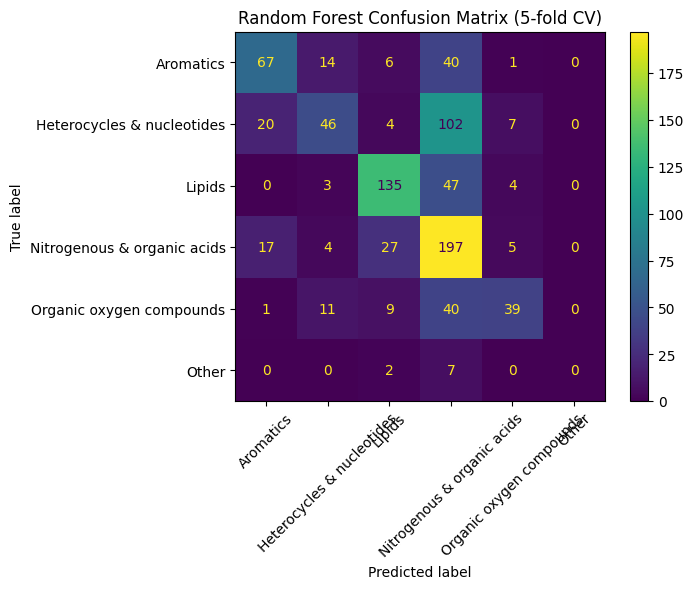

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Predict with cross-validation
y_pred = cross_val_predict(rf, X_scaled, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(xticks_rotation=45, cmap="viridis")
plt.title("Random Forest Confusion Matrix (5-fold CV)")
plt.show()
